In [1]:
import sys

print("Python version", sys.version)
print("Let's start the proj")

Python version 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Let's start the proj


In [2]:


import librosa
print("Librosa version", librosa.__version__)

import numpy as np
print("Numpy version", np.__version__)

import matplotlib.pyplot as plt


import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Librosa version 0.11.0
Numpy version 2.0.2
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
# CELL 4 — Load and inspect one audio file

import os
import librosa

DATASET_PATH = "/kaggle/input/datasets/yashdogra/speech-commands"

audio_path = os.path.join(DATASET_PATH, "yes", "4c6944d6_nohash_3.wav")

audio, sample_rate = librosa.load(audio_path, sr=None)

print("Audio path:", audio_path)
print("Audio shape:", audio.shape)
print("Sample rate:", sample_rate)
print("Duration:", len(audio) / sample_rate, "seconds")

Audio path: /kaggle/input/datasets/yashdogra/speech-commands/yes/4c6944d6_nohash_3.wav
Audio shape: (16000,)
Sample rate: 16000
Duration: 1.0 seconds


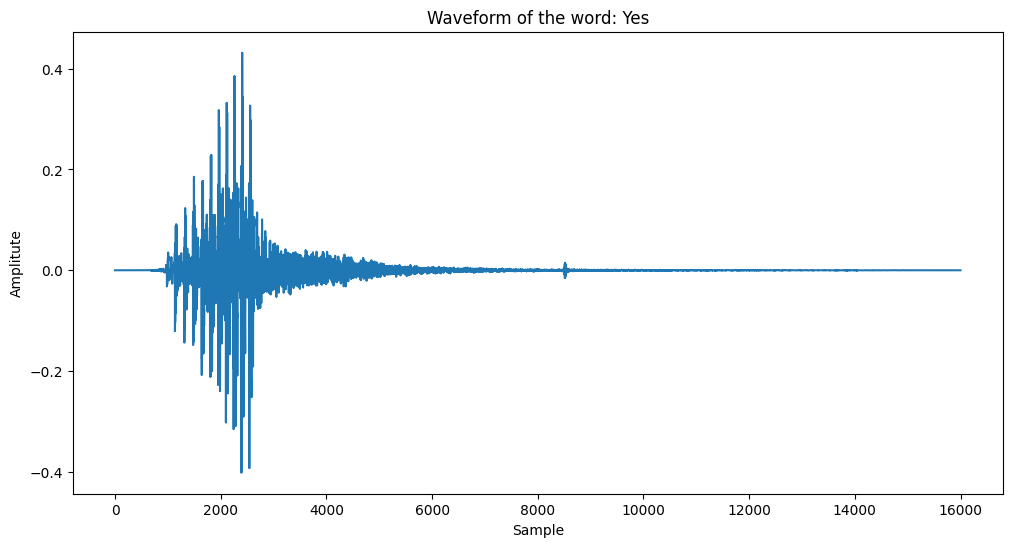

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize = (12, 6))

plt.plot(audio)

plt.title("Waveform of the word: Yes")
plt.xlabel("Sample")
plt.ylabel("Amplitute")

plt.show()

In [5]:
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

mel_spectrogram = librosa.feature.melspectrogram(
    y = audio,
    sr = sample_rate,
    n_mels = 64,
    n_fft = 1024,
    hop_length = 512
)

mel_db = librosa.power_to_db(
    mel_spectrogram,
    ref = np.max
)

print("Mel-spectrogram shape: ", mel_spectrogram.shape)

Mel-spectrogram shape:  (64, 32)


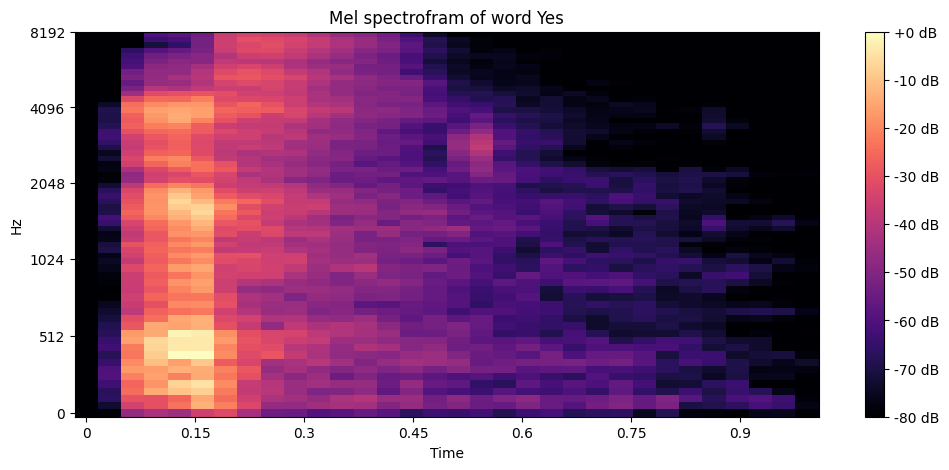

In [6]:
plt.figure(figsize = (12, 5))

librosa.display.specshow(
    mel_db,
    sr=sample_rate,
    hop_length=512,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format = "%+2.0f dB")
plt.title("Mel spectrofram of word Yes")
plt.show()

In [7]:

COMMANDS = [
    "yes",
    "no",
    "up",
    "down",
    "left",
    "right",
    "on",
    "off",
    "stop",
    "go"
]

print("Number of Classes: ", len(COMMANDS))
print("Commands: ", COMMANDS)

print("\nNumber of audio files: ")

for command in COMMANDS:
    command_path = os.path.join(DATASET_PATH, command)

    files = os.listdir(command_path)

    wav_files = [file for file in files if file.endswith(".wav")]

    print(command, ":", len(wav_files))


Number of Classes:  10
Commands:  ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']

Number of audio files: 
yes : 4044
no : 3941
up : 3723
down : 3917
left : 3801
right : 3778
on : 3845
off : 3745
stop : 3872
go : 3880


In [8]:
VALIDATION_FILE = os.path.join(DATASET_PATH, "validation_list.txt")

TEST_FILE = os.path.join(DATASET_PATH, "testing_list.txt")

with open(VALIDATION_FILE, "r") as file:
    validation_files = file.read().splitlines()

with open(TEST_FILE, "r") as file:
    test_files = file.read().splitlines()


print("Validation files: ", len(validation_files))
print("Test files: ", len(test_files))

print("\nFirst 5 validation files: ")
print(validation_files[:5])

print("\nFirst 5 test files: ")
print(test_files[:5])


Validation files:  9981
Test files:  11005

First 5 validation files: 
['right/a69b9b3e_nohash_0.wav', 'right/439c84f4_nohash_1.wav', 'right/409c962a_nohash_1.wav', 'right/dbaf8fc6_nohash_2.wav', 'right/a6d586b7_nohash_1.wav']

First 5 test files: 
['right/bb05582b_nohash_3.wav', 'right/97f4c236_nohash_2.wav', 'right/f2e59fea_nohash_3.wav', 'right/fdb5155e_nohash_2.wav', 'right/dc75148d_nohash_0.wav']


In [9]:
def audio_to_mel(audio_path):
    
    audio, sample_rate = librosa.load(
        audio_path,
        sr = 16000
    )

    target_length = 16000

    audio = librosa.util.fix_length(
        audio,
        size = target_length
    )

    mel_spectrogram = librosa.feature.melspectrogram(
        y = audio,
        sr = sample_rate,
        n_mels = 64,
        n_fft = 1024,
        hop_length = 512
    )

    mel_db = librosa.power_to_db(
        mel_spectrogram,
        ref = np.max
    )

    return mel_db

In [10]:
test_audio_path = os.path.join(
    DATASET_PATH,
    "yes",
    "4c6944d6_nohash_3.wav"
)

mel = audio_to_mel(test_audio_path)

print("Mel-spectrogram shape: ", mel.shape)

Mel-spectrogram shape:  (64, 32)


In [11]:
label_to_index = {
    command: index
    for index, command in enumerate(COMMANDS)
}

index_to_label = {
    index: command
    for command, index in label_to_index.items()
}

print("Label to index: ")
print(label_to_index)

print("Index to label")
print(index_to_label)

Label to index: 
{'yes': 0, 'no': 1, 'up': 2, 'down': 3, 'left': 4, 'right': 5, 'on': 6, 'off': 7, 'stop': 8, 'go': 9}
Index to label
{0: 'yes', 1: 'no', 2: 'up', 3: 'down', 4: 'left', 5: 'right', 6: 'on', 7: 'off', 8: 'stop', 9: 'go'}


In [12]:
import torch
from torch.utils.data import Dataset

class SpeechCommandsDataset(Dataset):

    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, index):

        audio_path = self.file_paths[index]
        label = self.labels[index]

        mel = audio_to_mel(audio_path)

        mel = torch.tensor(mel, dtype = torch.float32)

        label = torch.tensor(label, dtype = torch.long)

        return mel, label

In [13]:

def get_label_from_path(relative_path):
    command = relative_path.split("/")[0]
    return label_to_index[command]

def create_file_list(split):

    file_paths = []
    labels = []

    if split == "validation":
        selected_files = validation_files

    elif split == "test":
        selected_files = test_files

    elif split == "train":
        validation_set = set(validation_files)
        test_set = set(test_files)

        selected_files = []

        for command in COMMANDS:
            command_path = os.path.join(DATASET_PATH, command)

            for filename in os.listdir(command_path):
                if filename.endswith(".wav"):
                    relative_path = command + "/" + filename

                    if relative_path not in validation_set and relative_path not in test_set:
                        selected_files.append(relative_path)

    else:
        raise ValueError("split must be train, validation, or test")

    for relative_path in selected_files:

        command = relative_path.split("/")[0]

        if command in COMMANDS:

            full_path = os.path.join(DATASET_PATH, relative_path)

            label = label_to_index[command]

            file_paths.append(full_path)
            labels.append(label)

    return file_paths, labels

In [14]:
train_paths, train_labels = create_file_list("train")

validation_paths, validation_labels = create_file_list("validation")

test_paths, test_labels = create_file_list("test")


print("Training examples: ", len(train_paths))
print("Validation examples: ", len(validation_paths))
print("Test examples: ", len(test_paths))

Training examples:  30769
Validation examples:  3703
Test examples:  4074


In [15]:
for i in range(5):
    print("File: ", train_paths[i])
    print("Label number: ", train_labels[i])
    print("Label word: ", index_to_label[train_labels[i]])

File:  /kaggle/input/datasets/yashdogra/speech-commands/yes/4c6944d6_nohash_3.wav
Label number:  0
Label word:  yes
File:  /kaggle/input/datasets/yashdogra/speech-commands/yes/c08e5058_nohash_1.wav
Label number:  0
Label word:  yes
File:  /kaggle/input/datasets/yashdogra/speech-commands/yes/4e99c1b7_nohash_3.wav
Label number:  0
Label word:  yes
File:  /kaggle/input/datasets/yashdogra/speech-commands/yes/cb2929ce_nohash_3.wav
Label number:  0
Label word:  yes
File:  /kaggle/input/datasets/yashdogra/speech-commands/yes/aeb99b1c_nohash_1.wav
Label number:  0
Label word:  yes


In [16]:
test_mel = audio_to_mel(train_paths[0])

print("Mel shape:", test_mel.shape)

Mel shape: (64, 32)


In [17]:
for command in COMMANDS:

    command_path = os.path.join(DATASET_PATH, command)

    filename = os.listdir(command_path)[0]

    audio_path = os.path.join(command_path, filename)

    mel = audio_to_mel(audio_path)

    print(command, "->", mel.shape)

yes -> (64, 32)
no -> (64, 32)
up -> (64, 32)
down -> (64, 32)
left -> (64, 32)
right -> (64, 32)
on -> (64, 32)
off -> (64, 32)
stop -> (64, 32)
go -> (64, 32)


In [18]:
train_dataset = SpeechCommandsDataset(
    train_paths,
    train_labels
)

validation_dataset = SpeechCommandsDataset(
    validation_paths,
    validation_labels
)

test_dataset = SpeechCommandsDataset(
    test_paths,
    test_labels
)

In [19]:
mel, label = train_dataset[0]

print("Mel type:", type(mel))
print("Mel shape:", mel.shape)
print("Label:", label)
print("Label word:", index_to_label[label.item()])

Mel type: <class 'torch.Tensor'>
Mel shape: torch.Size([64, 32])
Label: tensor(0)
Label word: yes


In [20]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [21]:
mel_batch, label_batch = next(iter(train_loader))

print("Mel batch shape:", mel_batch.shape)
print("Label batch shape:", label_batch.shape)

print("First 10 labels:")
print(label_batch[:10])

print("First 10 words:")

for label in label_batch[:10]:
    print(index_to_label[label.item()])

Mel batch shape: torch.Size([32, 64, 32])
Label batch shape: torch.Size([32])
First 10 labels:
tensor([9, 7, 9, 3, 6, 2, 2, 2, 9, 6])
First 10 words:
go
off
go
down
on
up
up
up
go
on


In [22]:
import torch
import torch.nn as nn


class SpeechCommandCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            )
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                64 * 16 * 8,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        x = x.unsqueeze(1)

        x = self.features(x)

        x = self.classifier(x)

        return x

In [23]:
NUM_CLASSES = len(COMMANDS)

model = SpeechCommandCNN(
    num_classes=NUM_CLASSES
)

print(model)

SpeechCommandCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [24]:
mel_batch, label_batch = next(iter(train_loader))

outputs = model(mel_batch)

print("Input shape: ", mel_batch.shape)
print("Output shape: ", outputs.shape)

Input shape:  torch.Size([32, 64, 32])
Output shape:  torch.Size([32, 10])


In [25]:
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr = LEARNING_RATE
)

In [26]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device: ", device)

model = model.to(device)

print("Model device: ", next(model.parameters()).device)

Device:  cuda
Model device:  cuda:0


In [27]:
mel_batch, label_batch = next(iter(train_loader))

mel_batch = mel_batch.to(device)
label_batch = label_batch.to(device)

outputs = model(mel_batch)

loss = criterion(
    outputs,
    label_batch
)

print("Output shape: ", outputs.shape)
print("Loss: ", loss.item())

Output shape:  torch.Size([32, 10])
Loss:  4.233767032623291


In [28]:
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

print(
    "Model device:",
    next(model.parameters()).device
)

print(
    "GPU:",
    torch.cuda.get_device_name(0)
)

CUDA available: True
Device: cuda
Model device: cuda:0
GPU: Tesla T4


In [29]:
mel_batch, label_batch = next(iter(train_loader))

print("Before moving:")
print("Mel:", mel_batch.device)
print("Labels:", label_batch.device)

mel_batch = mel_batch.to(device)
label_batch = label_batch.to(device)

print("\nAfter moving:")
print("Mel:", mel_batch.device)
print("Labels:", label_batch.device)

outputs = model(mel_batch)

print("\nOutput:", outputs.device)

Before moving:
Mel: cpu
Labels: cpu

After moving:
Mel: cuda:0
Labels: cuda:0

Output: cuda:0


In [30]:
class FastSpeechCommandsDataset(Dataset):

    def __init__(self, file_paths, labels):

        self.labels = labels
        self.mels = []

        print("Precomputing Mel-spectrograms...")

        for i, audio_path in enumerate(file_paths):

            mel = audio_to_mel(audio_path)

            mel = torch.tensor(
                mel,
                dtype=torch.float32
            )

            self.mels.append(mel)

            if (i + 1) % 1000 == 0:
                print(
                    f"Processed {i + 1}/{len(file_paths)}"
                )

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, index):

        mel = self.mels[index]

        label = torch.tensor(
            self.labels[index],
            dtype=torch.long
        )

        return mel, label

In [31]:
fast_train_dataset = FastSpeechCommandsDataset(
    train_paths,
    train_labels
)

fast_validation_dataset = FastSpeechCommandsDataset(
    validation_paths,
    validation_labels
)

fast_test_dataset = FastSpeechCommandsDataset(
    test_paths,
    test_labels
)

Precomputing Mel-spectrograms...
Processed 1000/30769
Processed 2000/30769
Processed 3000/30769
Processed 4000/30769
Processed 5000/30769
Processed 6000/30769
Processed 7000/30769
Processed 8000/30769
Processed 9000/30769
Processed 10000/30769
Processed 11000/30769
Processed 12000/30769
Processed 13000/30769
Processed 14000/30769
Processed 15000/30769
Processed 16000/30769
Processed 17000/30769
Processed 18000/30769
Processed 19000/30769
Processed 20000/30769
Processed 21000/30769
Processed 22000/30769
Processed 23000/30769
Processed 24000/30769
Processed 25000/30769
Processed 26000/30769
Processed 27000/30769
Processed 28000/30769
Processed 29000/30769
Processed 30000/30769
Precomputing Mel-spectrograms...
Processed 1000/3703
Processed 2000/3703
Processed 3000/3703
Precomputing Mel-spectrograms...
Processed 1000/4074
Processed 2000/4074
Processed 3000/4074
Processed 4000/4074


In [32]:
BATCH_SIZE = 32

train_loader = DataLoader(
    fast_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_loader = DataLoader(
    fast_validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    fast_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [33]:
mel_batch, label_batch = next(iter(train_loader))

print("Mel batch:", mel_batch.shape)
print("Labels:", label_batch.shape)

Mel batch: torch.Size([32, 64, 32])
Labels: torch.Size([32])


In [34]:
BATCH_SIZE = 64

train_loader = DataLoader(
    fast_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

validation_loader = DataLoader(
    fast_validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    fast_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [35]:
NUM_CLASSES = len(COMMANDS)

model = SpeechCommandCNN(
    num_classes=NUM_CLASSES
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Model device:", next(model.parameters()).device)

Model device: cuda:0


In [36]:
import time

model.train()

start_time = time.time()

running_loss = 0.0
correct = 0
total = 0

for batch_index, (mel_batch, label_batch) in enumerate(train_loader):

    mel_batch = mel_batch.to(
        device,
        non_blocking=True
    )

    label_batch = label_batch.to(
        device,
        non_blocking=True
    )

    optimizer.zero_grad()

    outputs = model(mel_batch)

    loss = criterion(
        outputs,
        label_batch
    )

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

    predictions = outputs.argmax(dim=1)

    correct += (
        predictions == label_batch
    ).sum().item()

    total += label_batch.size(0)

    if (batch_index + 1) % 50 == 0:

        print(
            f"Batch {batch_index + 1}/{len(train_loader)}"
        )


epoch_loss = running_loss / len(train_loader)

epoch_accuracy = correct / total

elapsed_time = time.time() - start_time

print()
print("Training loss:", epoch_loss)
print("Training accuracy:", epoch_accuracy)
print("Time:", round(elapsed_time, 2), "seconds")

Batch 50/481
Batch 100/481
Batch 150/481
Batch 200/481
Batch 250/481
Batch 300/481
Batch 350/481
Batch 400/481
Batch 450/481

Training loss: 1.3269963376611285
Training accuracy: 0.5855893919204394
Time: 2.88 seconds


In [37]:
model.eval()

validation_loss = 0.0
validation_correct = 0
validation_total = 0

with torch.no_grad():

    for mel_batch, label_batch in validation_loader:

        mel_batch = mel_batch.to(
            device,
            non_blocking=True
        )

        label_batch = label_batch.to(
            device,
            non_blocking=True
        )

        outputs = model(mel_batch)

        loss = criterion(
            outputs,
            label_batch
        )

        validation_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        validation_correct += (
            predictions == label_batch
        ).sum().item()

        validation_total += label_batch.size(0)


validation_loss = (
    validation_loss / len(validation_loader)
)

validation_accuracy = (
    validation_correct / validation_total
)

print("Validation loss:", validation_loss)
print("Validation accuracy:", validation_accuracy)

Validation loss: 0.5672314966033245
Validation accuracy: 0.8109640831758034


In [38]:
print("================================")
print("Training")
print("================================")
print("Loss:", epoch_loss)
print("Accuracy:", epoch_accuracy)

print()

print("================================")
print("Validation")
print("================================")
print("Loss:", validation_loss)
print("Accuracy:", validation_accuracy)

Training
Loss: 1.3269963376611285
Accuracy: 0.5855893919204394

Validation
Loss: 0.5672314966033245
Accuracy: 0.8109640831758034


In [39]:
model = SpeechCommandCNN(
    num_classes=NUM_CLASSES
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [40]:
NUM_EPOCHS = 20

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0

for epoch in range(NUM_EPOCHS):

    # ==========================================
    # TRAINING
    # ==========================================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for mel_batch, label_batch in train_loader:

        mel_batch = mel_batch.to(
            device,
            non_blocking=True
        )

        label_batch = label_batch.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(mel_batch)

        loss = criterion(
            outputs,
            label_batch
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == label_batch
        ).sum().item()

        total += label_batch.size(0)

    train_loss = running_loss / len(train_loader)

    train_accuracy = correct / total


    # ==========================================
    # VALIDATION
    # ==========================================

    model.eval()

    validation_loss = 0.0
    validation_correct = 0
    validation_total = 0

    with torch.no_grad():

        for mel_batch, label_batch in validation_loader:

            mel_batch = mel_batch.to(
                device,
                non_blocking=True
            )

            label_batch = label_batch.to(
                device,
                non_blocking=True
            )

            outputs = model(mel_batch)

            loss = criterion(
                outputs,
                label_batch
            )

            validation_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            validation_correct += (
                predictions == label_batch
            ).sum().item()

            validation_total += label_batch.size(0)

    val_loss = (
        validation_loss / len(validation_loader)
    )

    val_accuracy = (
        validation_correct / validation_total
    )


    # ==========================================
    # SAVE HISTORY
    # ==========================================

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)


    # ==========================================
    # SAVE BEST MODEL
    # ==========================================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            "best_speech_command_cnn.pth"
        )


    # ==========================================
    # PRINT RESULTS
    # ==========================================

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch 01/20 | Train Loss: 1.6011 | Train Acc: 0.5049 | Val Loss: 0.6771 | Val Acc: 0.7767
Epoch 02/20 | Train Loss: 0.6742 | Train Acc: 0.7666 | Val Loss: 0.4909 | Val Acc: 0.8345
Epoch 03/20 | Train Loss: 0.5112 | Train Acc: 0.8227 | Val Loss: 0.3977 | Val Acc: 0.8642
Epoch 04/20 | Train Loss: 0.4300 | Train Acc: 0.8492 | Val Loss: 0.3780 | Val Acc: 0.8731
Epoch 05/20 | Train Loss: 0.3888 | Train Acc: 0.8630 | Val Loss: 0.3462 | Val Acc: 0.8833
Epoch 06/20 | Train Loss: 0.3480 | Train Acc: 0.8797 | Val Loss: 0.3223 | Val Acc: 0.8890
Epoch 07/20 | Train Loss: 0.3118 | Train Acc: 0.8889 | Val Loss: 0.3655 | Val Acc: 0.8833
Epoch 08/20 | Train Loss: 0.2835 | Train Acc: 0.9012 | Val Loss: 0.3154 | Val Acc: 0.8920
Epoch 09/20 | Train Loss: 0.2593 | Train Acc: 0.9092 | Val Loss: 0.3143 | Val Acc: 0.8936
Epoch 10/20 | Train Loss: 0.2490 | Train Acc: 0.9122 | Val Loss: 0.3554 | Val Acc: 0.8839
Epoch 11/20 | Train Loss: 0.2288 | Train Acc: 0.9183 | Val Loss: 0.3307 | Val Acc: 0.9012
Epoch 12/2

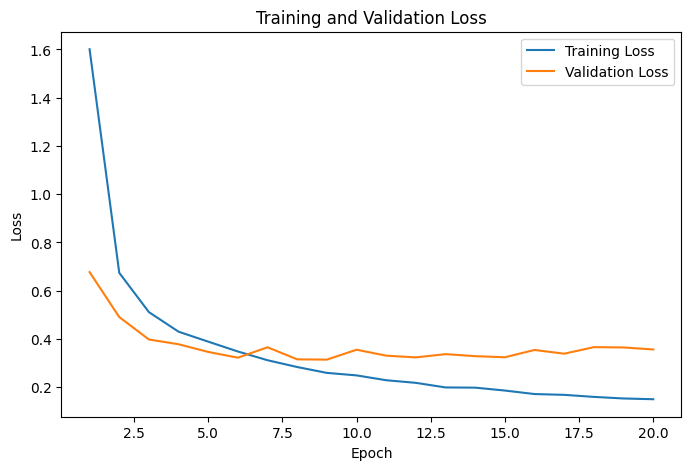

In [41]:
import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

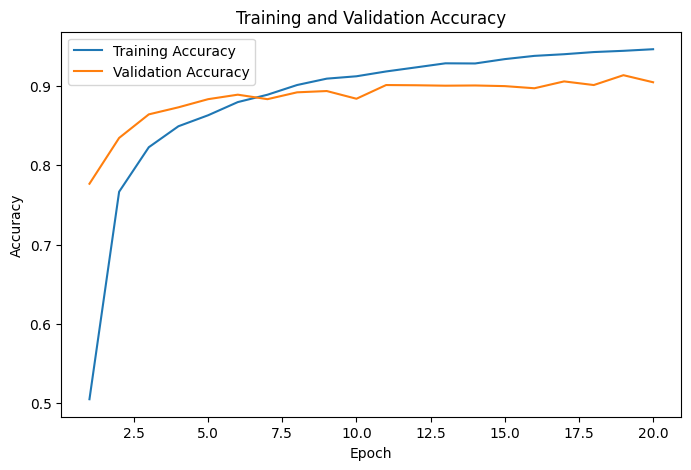

In [42]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

In [43]:
model.load_state_dict(
    torch.load(
        "best_speech_command_cnn.pth",
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)

print("Best model loaded.")
print("Best validation accuracy:", best_val_accuracy)

Best model loaded.
Best validation accuracy: 0.9135835808803673


In [44]:
model.train()

running_loss = 0.0
correct = 0
total = 0

for mel_batch, label_batch in train_loader:

    mel_batch = mel_batch.to(device)
    label_batch = label_batch.to(device)

    optimizer.zero_grad()

    outputs = model(mel_batch)

    loss = criterion(
        outputs,
        label_batch
    )

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

    predictions = outputs.argmax(dim = 1)

    correct += (predictions == label_batch).sum().item()

    total += label_batch.size(0)


epoch_loss = running_loss / len(train_loader)

epoch_accuracy = correct / total

print("Training loss: ", epoch_loss)
print("Training accuracy: ", epoch_accuracy)

Training loss:  0.14642992417817924
Training accuracy:  0.9483246124345932


In [45]:
# How to make Ai voice sound more humane with intentional noise, voice pull,
# ummmm, and other stuff
# add those noises randomly and trained by dataset

# Folder: /kaggle/input
# Folder: /kaggle/input/datasets
# Folder: /kaggle/input/datasets/yashdogra
# Folder: /kaggle/input/datasets/yashdogra/speech-commands
#    LICENSE
#    testing_list.txt
#    README.md
#    validation_list.txt
# Folder: /kaggle/input/datasets/yashdogra/speech-commands/no
#    4c6944d6_nohash_3.wav
#    4e99c1b7_nohash_3.wav
#    97f4c236_nohash_3.wav
#    cb2929ce_nohash_3.wav
#    ca4d5368_nohash_3.wav